In [ ]:
import pandas as pd
import pytest as pt
import seaborn as sns

In [ ]:

def alphabetical_player(mystery_word, guessed_letters, rounds_left):
    assert rounds_left > 0
    alphabet = "abcdefghijklmnopqrstuvwxyz"
    if (
        rounds_left > 0
    ):  # Should this be here if the orchestrator only calls it when rounds_left > 0? Should rounds_left just not be an argument for the players?
        for char in alphabet:
            if char in guessed_letters:
                continue
            return char

def vowel_first_player(mystery_word, guessed_letters, rounds_left):
    alphabet = "aeioubcdfghjklmnpqrstvwxyz"
    if rounds_left > 0:
        for char in alphabet:
            if char in guessed_letters:
                continue
            return char

def test_vowel_first_player(rounds_left):
    alphabet = "aeioubcdfghjklmnpqrstvwxyz"
    guessed_letters = []
    for i in range(len(alphabet)):
        if rounds_left - i > 0:
            assert (
                vowel_first_player(
                    "?????", guessed_letters, rounds_left - i
                )
                == alphabet[i]
            )
            guessed_letters.append(
                vowel_first_player(
                    "?????", guessed_letters, rounds_left - i
                )
            )
        else:
            assert (
                vowel_first_player(
                    "?????", guessed_letters, rounds_left - i
                )
                == None
            )

def letter_probability_player(mystery_word, guessed_letters, rounds_left):
    alphabet = "eariotnslcudpmhgbfywkvxzjq"
    if rounds_left>0:
        for char in alphabet:
            if char in guessed_letters:
                continue
            return char

def test_letter_probability_player(
    rounds_left,
):  # This doesn't work because the letter_probability_player doesn't have if rounds>0
    alphabet = "eariotnslcudpmhgbfywkvxzjq"
    guessed_letters = []
    for i in range(len(alphabet)):
        if rounds_left - i > 0:
            assert (
                letter_probability_player(
                    "?????", guessed_letters, rounds_left - i
                )
                == alphabet[i]
            )
            guessed_letters.append(
                letter_probability_player(
                    "?????", guessed_letters, rounds_left - i
                )
            )
        else:
            assert (
                letter_probability_player(
                    "?????", guessed_letters, rounds_left - i
                )
                == None
            )

def ing_ly_player(mystery_word, guessed_letters, rounds_left):
    alphabet = "eariotnslcudpmhgbfywkvxzjq"
    if rounds_left > 0:
        for char in alphabet:
            if char in guessed_letters:
                continue
            # ing
            if "n" not in guessed_letters:
                if "i" in guessed_letters:
                    if mystery_word[len(mystery_word) - 3] == "i":
                        return "n"
            if (
                "g"
                not in guessed_letters & "i"
                in guessed_letters & "n"
                in guessed_letters
            ):
                if (
                    mystery_word[len(mystery_word) - 3]
                    == "i" & mystery_word[len(mystery_word) - 2]
                    == "n"
                ):
                    return "g"

            # ly
            if (
                "y"
                not in guessed_letters & "l"
                in guessed_letters & mystery_word[len(mystery_word) - 2]
                == "l"
            ):
                return "y"

def test_ing_ly_player(rounds_left):
    alphabet = "eariotnslcudpmhgbfywkvxzjq"
    mystery_words = ["hurting", "funnily"]
    guessed_letters = []
    for word in mystery_words:
        for i in range(len(alphabet)):
            if rounds_left - i > 0:
                if word[len(word) - 3 : len(word) - 1] == "ing":
                    alphabet = "earingotslcudpmhbfywkvxzjq"
                    assert (
                        ing_ly_player(
                            word, guessed_letters, rounds_left - i
                        )
                        == alphabet[i]
                    )
                    guessed_letters.append(
                        ing_ly_player(
                            word, guessed_letters, rounds_left - i
                        )
                    )
                if word[len(word) - 2 : len(word) - 1] == "ly":
                    alphabet = "eariotnslycudpmhgbfwkvxzjq"
                    assert (
                        ing_ly_player(
                            word, guessed_letters, rounds_left - i
                        )
                        == alphabet[i]
                    )
                    guessed_letters.append(
                        ing_ly_player(
                            word, guessed_letters, rounds_left - i
                        )
                    )
            else:
                assert (
                    ing_ly_player(
                        "?????", guessed_letters, rounds_left - i
                    )
                    == None
                )

def orchestrator(hangman, player, word):
    secret_word = word
    mystery_word = ""
    for char in secret_word:
        mystery_word += "?"
    guessed_letters = []
    rounds_left = hangman

    while rounds_left > 0:
        guess = player(mystery_word, guessed_letters, rounds_left)
        guessed_letters.append(guess)
        rounds_left = rounds_left - 1

        mystery_temp = ""
        for i in range(len(secret_word)):
            if secret_word[i] == guess:
                mystery_temp += secret_word[i]
            else:
                mystery_temp += mystery_word[i]
        mystery_word = mystery_temp

        if mystery_word == secret_word:
            break

    return guessed_letters

def researcher(this_orchestrator, word_bank, player_list, num_words):
    column_1 = []
    for i in range(num_words):
        column_1.append(word_bank[i])
    column_1.append("Average Score")
    stats_table = pd.DataFrame({"Words": column_1})

    for player in player_list:
        data = []
        for i in range(num_words):
            guessed_letters = this_orchestrator(26, player, word_bank[i])
            data.append(len(guessed_letters))
        data.append(sum(data) / num_words)

        stats_table[player.__name__] = data

    return stats_table

In [ ]:
@pt.mark.parametrize('rounds_left', range(26))
def test_alphabetical_player(rounds_left):
    # Should you make it go through all words/word lengths, like why are we doing this and how do you determine wht to put as the args, this seems kind of obvious.
    alphabet = "abcdefghijklmnopqrstuvwxyz"
    guessed_letters = []
    for i in range(len(alphabet)):
        if rounds_left - i > 0:
            assert (
                alphabetical_player(
                    "?????", guessed_letters, rounds_left - i
                )
                == alphabet[i]
            )
            # mystery_word won't update but does that matter if algo doesn't depend on mystery_word at all?
            guessed_letters.append(
                alphabetical_player(
                    "?????", guessed_letters, rounds_left - i
                )
            )


..........................                                               [100%]
=================================== Overview ===================================
Passed Tests:
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[0]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[1]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[2]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[3]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[4]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[5]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[6]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[7]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[8]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[9]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[10]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[11]
✓ bindle/2026-10-07-hangman.py::test_alphabetical_player[12]
✓ bindle/2026-10-07-hangman.py::test_alpha

In [ ]:
test_ing_ly_player(7)

In [ ]:
researcher(
    orchestrator,
    ["socks", "keyboard", "letter", "popcorn"],
    [alphabetical_player, vowel_first_player, letter_probability_player],
    3,
)

,Words,alphabetical_player,vowel_first_player,letter_probability_player
0,socks,19.000000,20.0,21.0
1,keyboard,25.000000,25.0,21.0
2,letter,20.000000,21.0,9.0
3,Average Score,21.333333,22.0,17.0


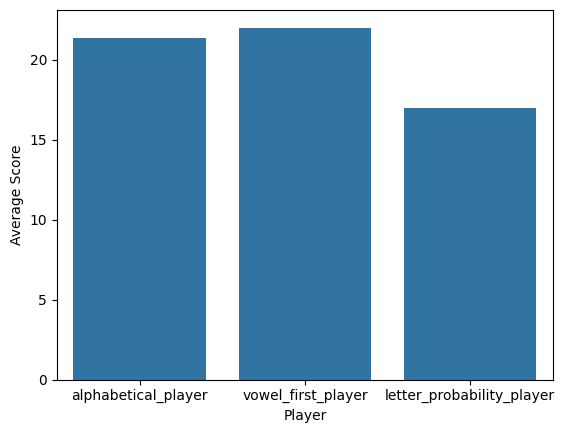

In [ ]:

stats_table = researcher(
    orchestrator,
    ["socks", "keyboard", "letter", "popcorn"],
    [alphabetical_player, vowel_first_player, letter_probability_player],
    3,
)

nstats_table = stats_table.loc[3].to_frame()
nstats_table.reset_index(inplace=True)
nstats_table.drop(index=0, inplace=True)
nstats_table.rename(
    columns={"index": "Player", 3: "Average Score"}, inplace=True
)
# nstats_table
sns.barplot(data=nstats_table, x="Player", y="Average Score")